# ⭐ Day 50: End-to-End EDA Pipeline
## Build Your Own Reusable EDA Template for AI & ML

**Day 50 of 369-day Python & AI Learning Path** 🚀

*The culmination of the entire EDA phase (Days 31–50)*


## 🎉 Welcome to Day 50!

Congratulations! You've reached a major milestone in your Python & AI journey. Day 50 marks the completion of our comprehensive **Exploratory Data Analysis (EDA) Mastery Phase** — a 20-day deep dive into understanding, cleaning, visualizing, and preparing data for machine learning.

Today is not just another lesson; it's a celebration of everything you've learned. From the humble beginnings of basic data inspection to advanced techniques like statistical analysis, outlier detection, correlation matrices, and feature importance — you've built a formidable skillset that separates amateur data enthusiasts from professional data scientists.

But here's the best part: **we're not just reviewing concepts today. We're building something permanent.** By the end of this notebook, you'll have a complete, reusable, end-to-end EDA pipeline — a professional-grade Python class that you can drop onto any dataset and instantly generate insights, visualizations, and reports. This is the tool you'll use for years to come.

Whether you're analyzing house prices, customer churn, medical records, or financial markets, this pipeline will be your trusted companion. It's modular, extensible, and designed with real-world production scenarios in mind. Let's build your legacy tool! 🛠️


## 📋 Table of Contents

1. [Why a Reusable EDA Pipeline Matters](#1-why-a-reusable-eda-pipeline-matters)
2. [Project Overview: Building a Flexible EDA Class/Pipeline](#2-project-overview-building-a-flexible-eda-classpipeline)
3. [Step 1: Data Loading & Initial Inspection](#3-step-1-data-loading--initial-inspection)
4. [Step 2: Missing Value Analysis](#4-step-2-missing-value-analysis)
5. [Step 3: Outlier Detection & Treatment](#5-step-3-outlier-detection--treatment)
6. [Step 4: Feature Distribution & Skewness Analysis](#6-step-4-feature-distribution--skewness-analysis)
7. [Step 5: Correlation Analysis & Heatmaps](#7-step-5-correlation-analysis--heatmaps)
8. [Step 6: Categorical Encoding Exploration](#8-step-6-categorical-encoding-exploration)
9. [Step 7: Preliminary Feature Importance with SHAP](#9-step-7-preliminary-feature-importance-with-shap)
10. [Step 8: Automated Insights Summary & Report Generation](#10-step-8-automated-insights-summary--report-generation)
11. [Creating a Reusable EDA Pipeline Class](#11-creating-a-reusable-eda-pipeline-class)
12. [Running the Pipeline on a New Dataset](#12-running-the-pipeline-on-a-new-dataset)
13. [Hands-On Exercises & Challenges](#hands-on-exercises--challenges)
14. [Solutions & Advanced Extensions](#solutions--advanced-extensions)


## 1. Why a Reusable EDA Pipeline Matters

In the real world of data science, **repetition is the enemy of productivity**. Every new project starts with the same questions:
- What does the data look like?
- What's missing?
- Where are the outliers?
- Which features matter?

Without a pipeline, you're rewriting the same code, copying from old notebooks, and inevitably making mistakes. A reusable EDA pipeline:

✅ **Saves Time**: Drop your data in, get instant insights out  
✅ **Ensures Consistency**: No steps forgotten, no corners cut  
✅ **Improves Quality**: Battle-tested code, professional visualizations  
✅ **Enables Collaboration**: Team members can use and extend your work  
✅ **Scales with You**: From small CSV files to massive datasets  

Today, we build your personal data analysis superpower. 💪


## 2. Project Overview: Building a Flexible EDA Class/Pipeline

Our pipeline will be built as a Python class called `EDAPipeline` with the following architecture:

```
EDAPipeline
├── load_data()
├── initial_inspection()
├── missing_value_analysis()
├── outlier_detection()
├── distribution_analysis()
├── correlation_analysis()
├── categorical_exploration()
├── feature_importance_analysis()
├── generate_report()
└── run_full_pipeline()
```

Let's start by setting up our environment and importing the necessary libraries.


In [1]:
# Cell 1: Environment Setup & Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
import json
from datetime import datetime
import os

# Optional: SHAP for feature importance (install if needed)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed. Feature importance will use sklearn's built-in method.")

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print("✅ Environment setup complete!")
print(f"📊 Libraries loaded: pandas, numpy, matplotlib, seaborn, scipy, sklearn")
print(f"🔍 SHAP available: {SHAP_AVAILABLE}")


✅ Environment setup complete!
📊 Libraries loaded: pandas, numpy, matplotlib, seaborn, scipy, sklearn
🔍 SHAP available: True


## 3. Step 1: Data Loading & Initial Inspection

Every EDA begins with understanding what we're working with. This step provides the "big picture" view of your dataset.


In [2]:
# Cell 2: Load Sample Dataset (California Housing - built-in)
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target

# Add some synthetic categorical features for demonstration
np.random.seed(42)
df['Location_Type'] = np.random.choice(['Urban', 'Suburban', 'Rural'], size=len(df))
df['Property_Age'] = np.random.choice(['New', 'Old', 'Vintage'], size=len(df))

# Introduce some missing values for demonstration (5% random)
mask = np.random.random(df.shape) < 0.05
df_missing = df.copy()
for col in ['AveRooms', 'AveBedrms', 'Population']:
    df_missing.loc[mask[:, df.columns.get_loc(col)], col] = np.nan

print("🎯 Dataset loaded successfully!")
print(f"📐 Shape: {df_missing.shape[0]} rows × {df_missing.shape[1]} columns")
print(f"\n📋 Column Names:\n{list(df_missing.columns)}")


🎯 Dataset loaded successfully!
📐 Shape: 20640 rows × 11 columns

📋 Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Target', 'Location_Type', 'Property_Age']


In [3]:
# Cell 3: Initial Inspection Function
def initial_inspection(dataframe):
    """
    Comprehensive initial inspection of the dataset.
    Returns a dictionary of insights.
    """
    insights = {}
    
    print("=" * 60)
    print("🔍 INITIAL DATA INSPECTION")
    print("=" * 60)
    
    # Basic info
    print(f"\n📊 Dataset Shape: {dataframe.shape}")
    print(f"💾 Memory Usage: {dataframe.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Data types
    print(f"\n📋 Data Types:")
    print(dataframe.dtypes.value_counts())
    
    # Column details
    print(f"\n📑 Column Details:")
    col_info = pd.DataFrame({
        'Type': dataframe.dtypes,
        'Non-Null': dataframe.count(),
        'Null': dataframe.isnull().sum(),
        'Null%': (dataframe.isnull().sum() / len(dataframe) * 100).round(2),
        'Unique': dataframe.nunique()
    })
    print(col_info)
    
    # Duplicates
    duplicates = dataframe.duplicated().sum()
    print(f"\n🔄 Duplicate Rows: {duplicates}")
    
    # First look
    print(f"\n👀 First 5 Rows:")
    display(dataframe.head())
    
    # Store insights
    insights['shape'] = dataframe.shape
    insights['memory_mb'] = dataframe.memory_usage(deep=True).sum() / 1024**2
    insights['total_nulls'] = dataframe.isnull().sum().sum()
    insights['duplicate_rows'] = duplicates
    insights['column_types'] = dict(dataframe.dtypes.value_counts())
    
    return insights

# Run inspection
initial_insights = initial_inspection(df_missing)


🔍 INITIAL DATA INSPECTION

📊 Dataset Shape: (20640, 11)
💾 Memory Usage: 1.94 MB

📋 Data Types:
float64    9
str        2
Name: count, dtype: int64

📑 Column Details:
                  Type  Non-Null  Null  Null%  Unique
MedInc         float64     20640     0  0.000   12928
HouseAge       float64     20640     0  0.000      52
AveRooms       float64     19626  1014  4.910   18479
AveBedrms      float64     19589  1051  5.090   13679
Population     float64     19612  1028  4.980    3831
AveOccup       float64     20640     0  0.000   18841
Latitude       float64     20640     0  0.000     862
Longitude      float64     20640     0  0.000     844
Target         float64     20640     0  0.000    3842
Location_Type      str     20640     0  0.000       3
Property_Age       str     20640     0  0.000       3

🔄 Duplicate Rows: 0

👀 First 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target,Location_Type,Property_Age
0,8.325,41.000,6.984,1.024,322.000,2.556,37.880,-122.230,4.526,Rural,Old
1,8.301,21.000,6.238,0.972,2401.000,2.110,37.860,-122.220,3.585,Urban,Vintage
2,7.257,52.000,8.288,1.073,496.000,2.802,37.850,-122.240,3.521,Rural,Old
3,5.643,52.000,5.817,1.073,558.000,2.548,37.850,-122.250,3.413,Rural,New
4,3.846,52.000,6.282,1.081,565.000,2.181,37.850,-122.250,3.422,Urban,Vintage


## 4. Step 2: Missing Value Analysis

Missing data is one of the most common challenges in real-world datasets. Understanding the pattern of missingness is crucial for proper treatment.



❓ MISSING VALUE ANALYSIS

📊 Columns with Missing Values:
            Missing Count  Missing %
AveBedrms            1051      5.090
Population           1028      4.980
AveRooms             1014      4.910


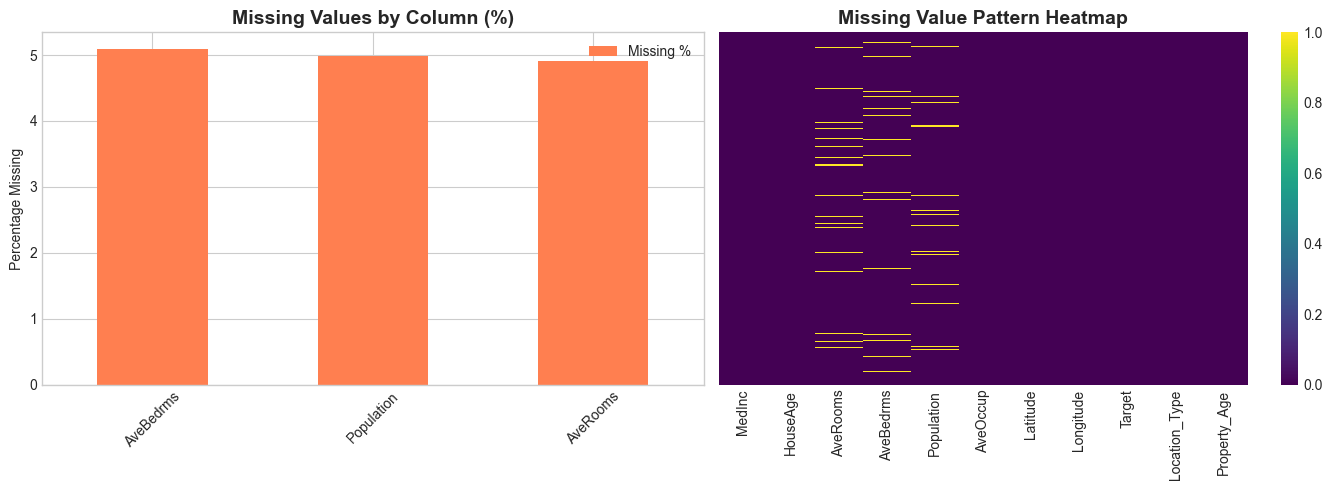


🔍 Missingness Patterns:
   • Total missing values: 3093
   • Columns affected: 3
   • Most affected: AveBedrms (5.09%)


In [4]:
# Cell 4: Missing Value Analysis Function
def analyze_missing_values(dataframe):
    """
    Comprehensive missing value analysis with visualizations.
    """
    print("\n" + "=" * 60)
    print("❓ MISSING VALUE ANALYSIS")
    print("=" * 60)
    
    # Calculate missing statistics
    missing = dataframe.isnull().sum()
    missing_pct = (missing / len(dataframe) * 100).round(2)
    
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    
    if missing_df.empty:
        print("✅ No missing values found!")
        return {}
    
    print(f"\n📊 Columns with Missing Values:")
    print(missing_df)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot
    missing_df.plot(kind='bar', y='Missing %', ax=axes[0], color='coral')
    axes[0].set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Percentage Missing')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Heatmap of missing values
    sns.heatmap(dataframe.isnull(), cbar=True, yticklabels=False, 
                cmap='viridis', ax=axes[1])
    axes[1].set_title('Missing Value Pattern Heatmap', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Missingness patterns
    print(f"\n🔍 Missingness Patterns:")
    print(f"   • Total missing values: {missing.sum()}")
    print(f"   • Columns affected: {len(missing_df)}")
    print(f"   • Most affected: {missing_df.index[0]} ({missing_df.iloc[0]['Missing %']}%)")
    
    return missing_df.to_dict()

missing_insights = analyze_missing_values(df_missing)


## 5. Step 3: Outlier Detection & Treatment

Outliers can significantly impact model performance. We use statistical methods (IQR, Z-score) to identify and handle them.



📈 OUTLIER DETECTION & ANALYSIS

📊 Outlier Summary (Method: IQR):
           count percentage                                      bounds
AveBedrms   1362      6.950     (0.8659773912603173, 1.239034254898982)
Population  1134      5.780                            (-621.5, 3134.5)
Target      1071      5.190    (-0.9808749999999995, 4.824124999999999)
AveOccup     711      3.440    (1.1509614824735064, 4.5610405893536905)
MedInc       681      3.300    (-0.7063750000000004, 8.013024999999999)
AveRooms     478      2.440      (2.018100459339621, 8.468074246409245)
HouseAge       0      0.000                               (-10.5, 65.5)
Latitude       0      0.000                 (28.259999999999998, 43.38)
Longitude      0      0.000  (-127.48499999999999, -112.32500000000002)


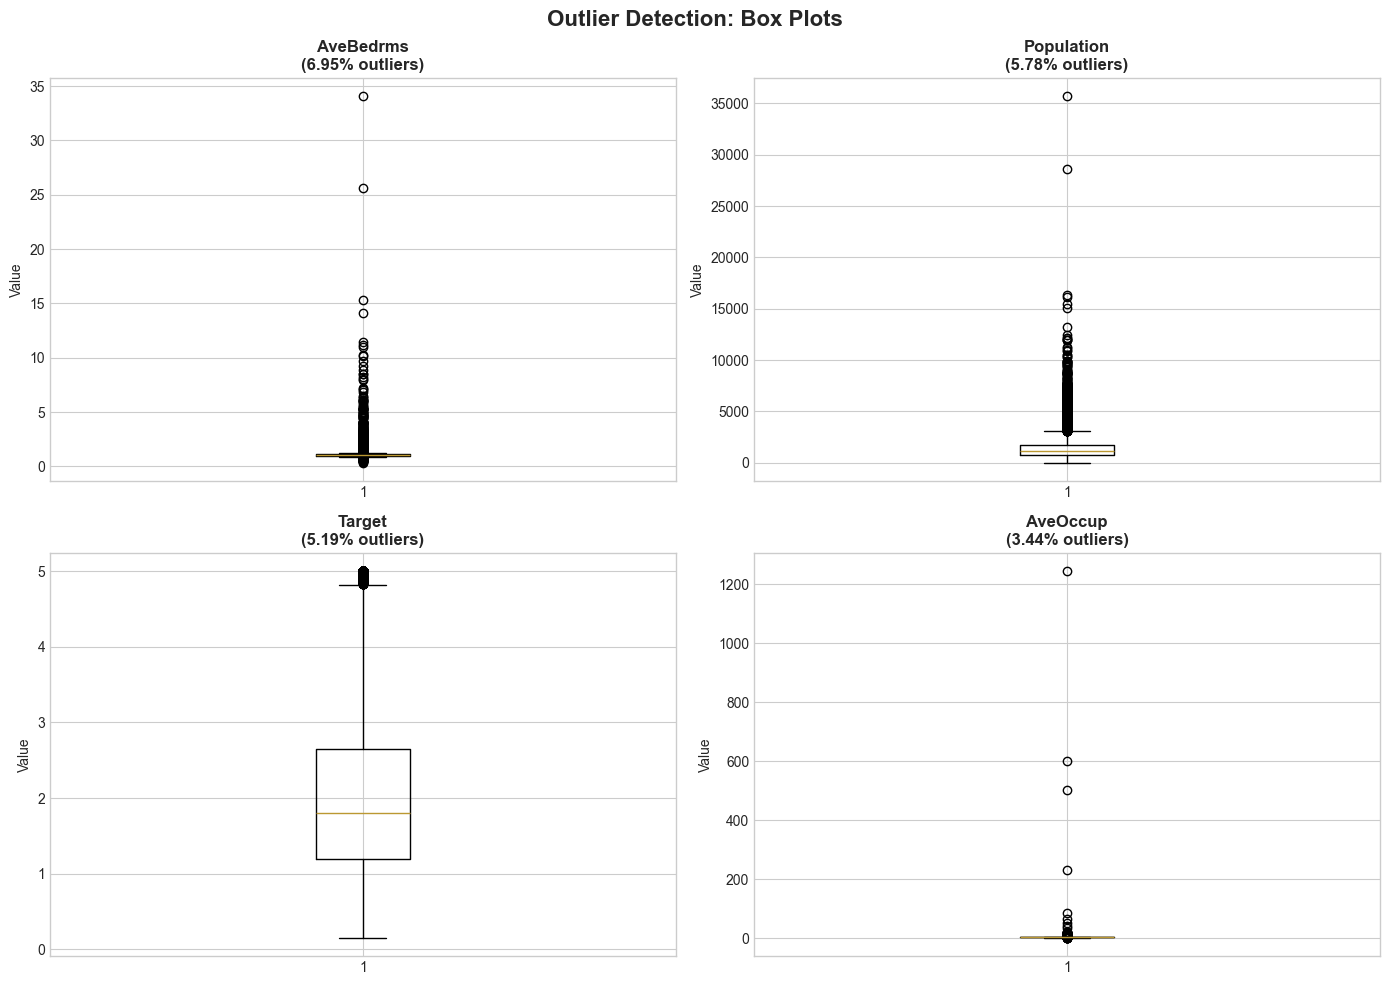

In [5]:
# Cell 5: Outlier Detection Function
def detect_outliers(dataframe, numerical_cols=None, method='iqr'):
    """
    Detect outliers using IQR or Z-score method.
    """
    print("\n" + "=" * 60)
    print("📈 OUTLIER DETECTION & ANALYSIS")
    print("=" * 60)
    
    if numerical_cols is None:
        numerical_cols = dataframe.select_dtypes(include=[np.number]).columns.tolist()
    
    outlier_summary = {}
    
    for col in numerical_cols:
        if col not in dataframe.columns:
            continue
            
        data = dataframe[col].dropna()
        
        if method == 'iqr':
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = data[(data < lower_bound) | (data > upper_bound)]
        else:  # z-score
            z_scores = np.abs(stats.zscore(data))
            outliers = data[z_scores > 3]
        
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(data)) * 100
        
        outlier_summary[col] = {
            'count': outlier_count,
            'percentage': round(outlier_pct, 2),
            'bounds': (lower_bound, upper_bound) if method == 'iqr' else None
        }
    
    # Display summary
    summary_df = pd.DataFrame(outlier_summary).T
    if not summary_df.empty:
        print(f"\n📊 Outlier Summary (Method: {method.upper()}):")
        print(summary_df.sort_values('percentage', ascending=False))
    
    # Visualization for top 4 columns with most outliers
    top_outlier_cols = summary_df.sort_values('percentage', ascending=False).head(4).index
    
    if len(top_outlier_cols) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        for idx, col in enumerate(top_outlier_cols):
            if idx < 4:
                axes[idx].boxplot(dataframe[col].dropna(), vert=True)
                axes[idx].set_title(f'{col}\n({summary_df.loc[col, "percentage"]}% outliers)', 
                                   fontsize=12, fontweight='bold')
                axes[idx].set_ylabel('Value')
        
        plt.suptitle('Outlier Detection: Box Plots', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return outlier_summary

numerical_columns = df_missing.select_dtypes(include=[np.number]).columns.tolist()
outlier_insights = detect_outliers(df_missing, numerical_columns, method='iqr')


## 6. Step 4: Feature Distribution & Skewness Analysis

Understanding the distribution of your features helps determine if transformations are needed (e.g., log transform for skewed data).



📊 FEATURE DISTRIBUTION & SKEWNESS ANALYSIS

📈 Distribution Statistics:
   Feature  Skewness  Kurtosis     Mean   Median      Std
    MedInc     1.647     4.951    3.871    3.535    1.900
  HouseAge     0.060    -0.801   28.639   29.000   12.586
  AveRooms    17.714   743.100    5.420    5.228    2.308
 AveBedrms    30.899  1581.977    1.097    1.049    0.484
Population     5.003    75.743 1426.492 1167.000 1134.992
  AveOccup    97.632 10648.430    3.071    2.818   10.386
  Latitude     0.466    -1.118   35.632   34.260    2.136
 Longitude    -0.298    -1.330 -119.570 -118.490    2.004
    Target     0.978     0.328    2.069    1.797    1.154

⚠️ Highly Skewed Features (|skew| > 1): ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']


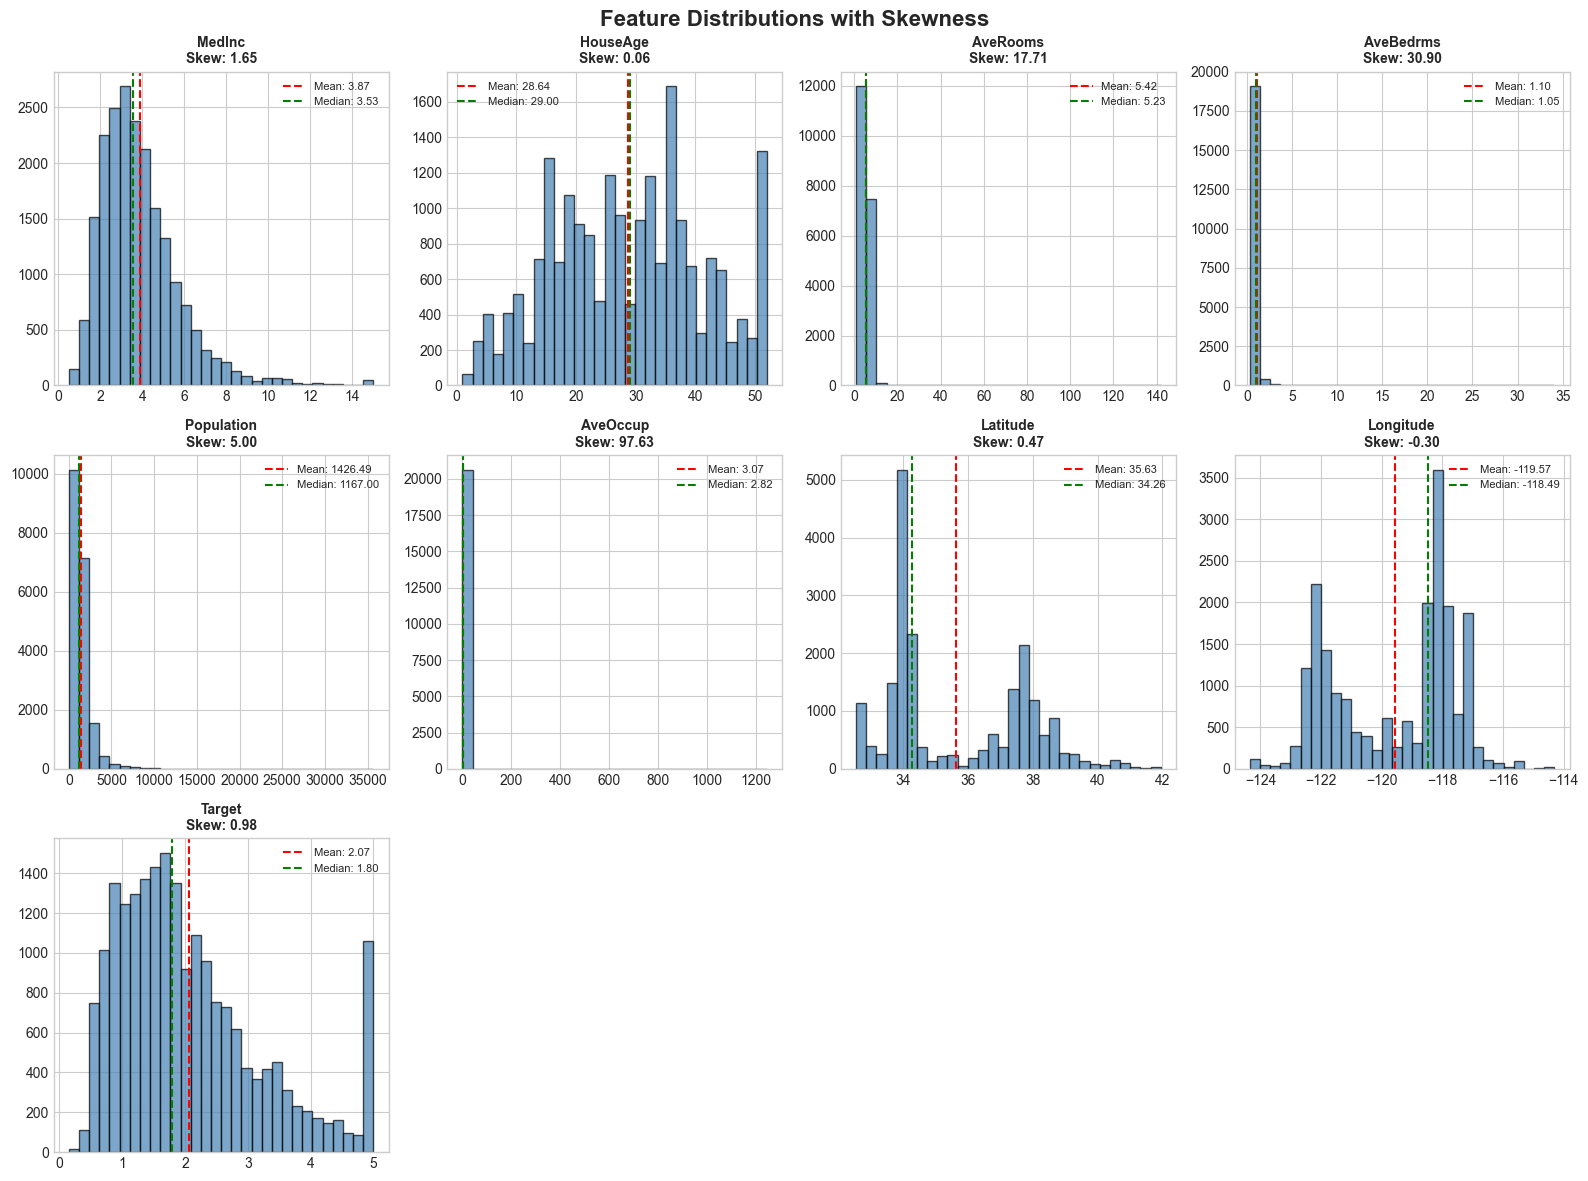

In [6]:
# Cell 6: Distribution & Skewness Analysis
def analyze_distributions(dataframe, numerical_cols=None):
    """
    Analyze feature distributions and skewness.
    """
    print("\n" + "=" * 60)
    print("📊 FEATURE DISTRIBUTION & SKEWNESS ANALYSIS")
    print("=" * 60)
    
    if numerical_cols is None:
        numerical_cols = dataframe.select_dtypes(include=[np.number]).columns.tolist()
    
    skewness_data = []
    
    # Calculate statistics
    for col in numerical_cols:
        if col not in dataframe.columns:
            continue
        data = dataframe[col].dropna()
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)
        
        skewness_data.append({
            'Feature': col,
            'Skewness': round(skewness, 3),
            'Kurtosis': round(kurtosis, 3),
            'Mean': round(data.mean(), 3),
            'Median': round(data.median(), 3),
            'Std': round(data.std(), 3)
        })
    
    skew_df = pd.DataFrame(skewness_data)
    print("\n📈 Distribution Statistics:")
    print(skew_df.to_string(index=False))
    
    # Identify highly skewed features
    highly_skewed = skew_df[abs(skew_df['Skewness']) > 1]['Feature'].tolist()
    print(f"\n⚠️ Highly Skewed Features (|skew| > 1): {highly_skewed}")
    
    # Visualization
    n_cols = min(4, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            data = dataframe[col].dropna()
            axes[idx].hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
            axes[idx].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
            axes[idx].axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.2f}')
            axes[idx].set_title(f'{col}\nSkew: {stats.skew(data):.2f}', fontsize=10, fontweight='bold')
            axes[idx].legend(fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Feature Distributions with Skewness', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return skew_df.to_dict('records')

distribution_insights = analyze_distributions(df_missing, numerical_columns)


## 7. Step 5: Correlation Analysis & Heatmaps

Correlation analysis reveals relationships between features and helps identify multicollinearity issues.



🔗 CORRELATION ANALYSIS


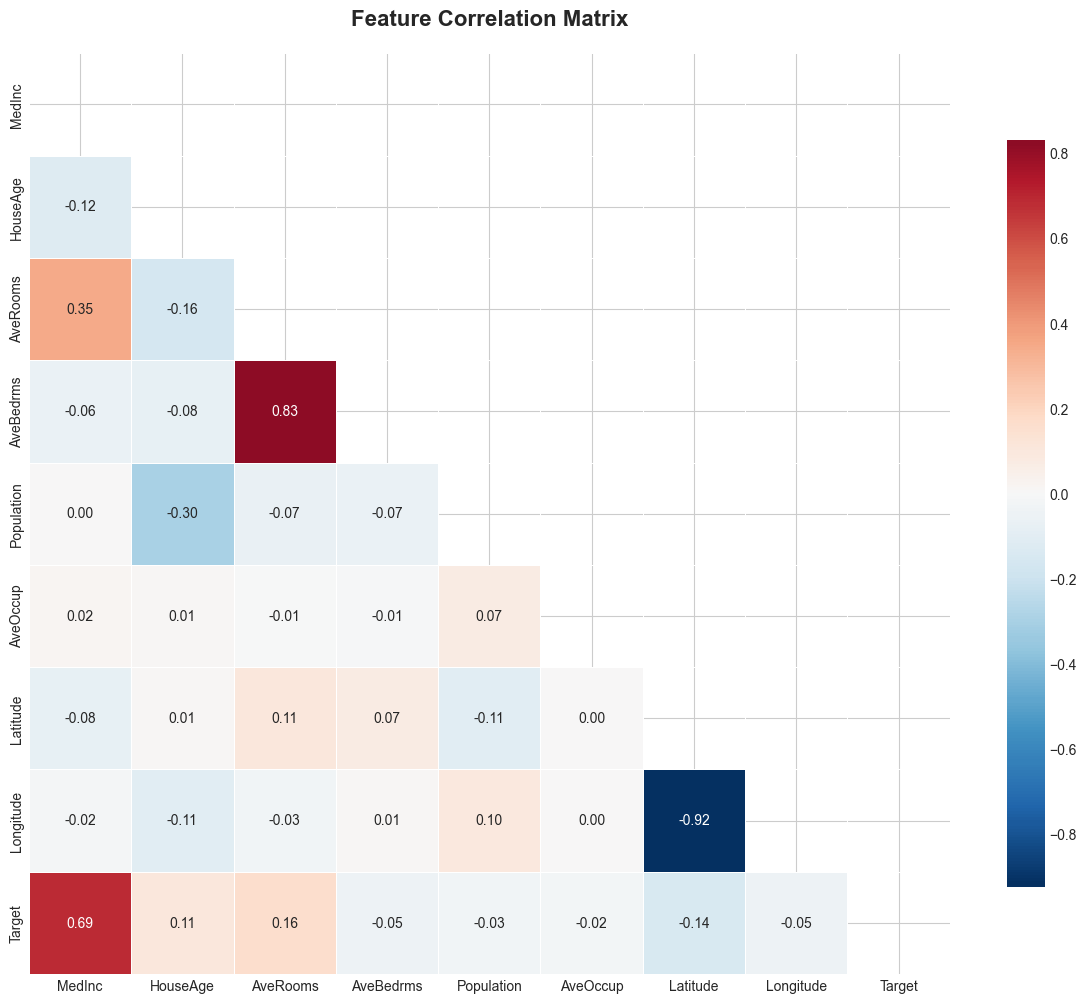


🎯 Correlations with Target ('Target'):
MedInc        0.688
AveRooms      0.162
Latitude     -0.144
HouseAge      0.106
AveBedrms    -0.047
Longitude    -0.046
Population   -0.027
AveOccup     -0.024
Name: Target, dtype: float64


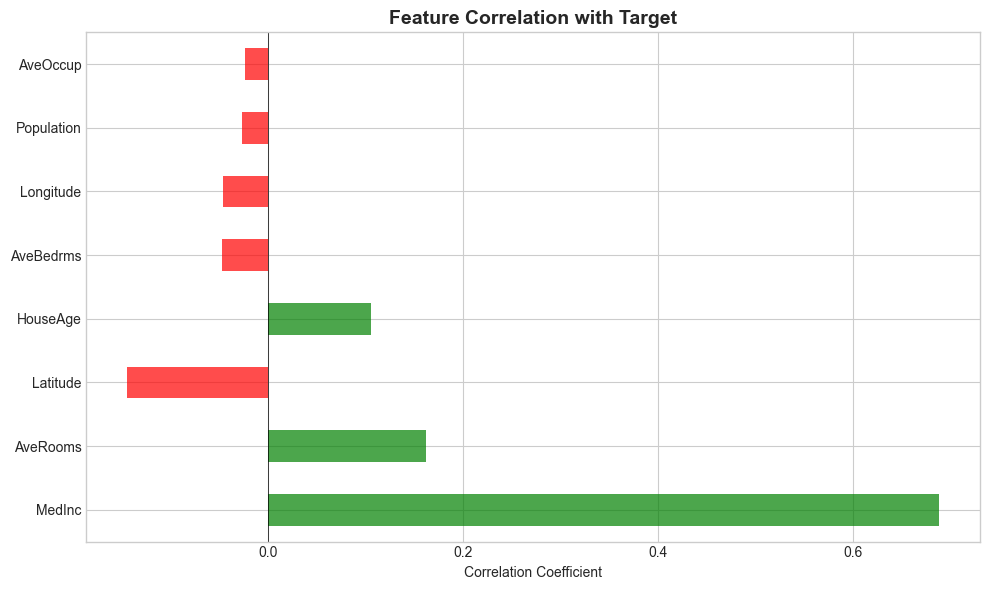


⚠️ High Correlation Pairs (|r| > 0.7) - Potential Multicollinearity:
Feature 1 Feature 2  Correlation
 AveRooms AveBedrms        0.831
 Latitude Longitude       -0.925


In [7]:
# Cell 7: Correlation Analysis
def analyze_correlations(dataframe, target_col='Target'):
    """
    Comprehensive correlation analysis with heatmaps.
    """
    print("\n" + "=" * 60)
    print("🔗 CORRELATION ANALYSIS")
    print("=" * 60)
    
    # Select numerical columns
    numerical_df = dataframe.select_dtypes(include=[np.number])
    
    # Calculate correlation matrix
    corr_matrix = numerical_df.corr()
    
    # Full heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Target correlations
    if target_col in corr_matrix.columns:
        target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)
        print(f"\n🎯 Correlations with Target ('{target_col}'):")
        print(target_corr)
        
        # Bar plot of target correlations
        plt.figure(figsize=(10, 6))
        colors = ['green' if x > 0 else 'red' for x in target_corr.values]
        target_corr.plot(kind='barh', color=colors, alpha=0.7)
        plt.title(f'Feature Correlation with {target_col}', fontsize=14, fontweight='bold')
        plt.xlabel('Correlation Coefficient')
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.show()
    
    # High correlation pairs (potential multicollinearity)
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': round(corr_matrix.iloc[i, j], 3)
                })
    
    if high_corr_pairs:
        print(f"\n⚠️ High Correlation Pairs (|r| > 0.7) - Potential Multicollinearity:")
        high_corr_df = pd.DataFrame(high_corr_pairs)
        print(high_corr_df.to_string(index=False))
    else:
        print(f"\n✅ No high correlation pairs found (all |r| < 0.7)")
    
    return {
        'correlation_matrix': corr_matrix.to_dict(),
        'target_correlations': target_corr.to_dict() if target_col in corr_matrix.columns else {},
        'high_correlation_pairs': high_corr_pairs
    }

correlation_insights = analyze_correlations(df_missing, target_col='Target')


## 8. Step 6: Categorical Encoding Exploration

Understanding categorical variables and their encoding options is essential for ML preprocessing.



🏷️ CATEGORICAL FEATURE EXPLORATION

📌 Feature: Location_Type
----------------------------------------
   Unique Values: 3
   Missing: 0 (0.00%)
   Most Common: Urban (6926 occurrences)
   💡 Encoding Recommendation: One-Hot Encoding (low cardinality)

📌 Feature: Property_Age
----------------------------------------
   Unique Values: 3
   Missing: 0 (0.00%)
   Most Common: New (6952 occurrences)
   💡 Encoding Recommendation: One-Hot Encoding (low cardinality)


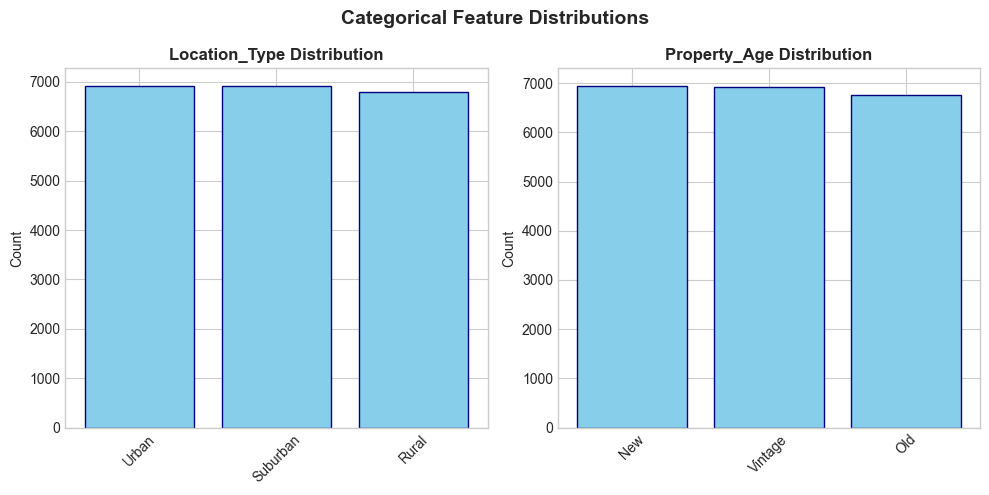

In [8]:
# Cell 8: Categorical Exploration
def explore_categorical(dataframe, categorical_cols=None):
    """
    Explore categorical features and encoding options.
    """
    print("\n" + "=" * 60)
    print("🏷️ CATEGORICAL FEATURE EXPLORATION")
    print("=" * 60)
    
    if categorical_cols is None:
        categorical_cols = dataframe.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not categorical_cols:
        print("ℹ️ No categorical columns found.")
        return {}
    
    cat_insights = {}
    
    for col in categorical_cols:
        print(f"\n📌 Feature: {col}")
        print("-" * 40)
        
        value_counts = dataframe[col].value_counts()
        unique_count = dataframe[col].nunique()
        null_count = dataframe[col].isnull().sum()
        
        print(f"   Unique Values: {unique_count}")
        print(f"   Missing: {null_count} ({null_count/len(dataframe)*100:.2f}%)")
        print(f"   Most Common: {value_counts.index[0]} ({value_counts.iloc[0]} occurrences)")
        
        # Cardinality assessment
        if unique_count <= 5:
            encoding_rec = "One-Hot Encoding (low cardinality)"
        elif unique_count <= 20:
            encoding_rec = "One-Hot or Target Encoding (medium cardinality)"
        else:
            encoding_rec = "Target Encoding or Embeddings (high cardinality)"
        
        print(f"   💡 Encoding Recommendation: {encoding_rec}")
        
        cat_insights[col] = {
            'unique_count': unique_count,
            'missing_count': null_count,
            'top_category': value_counts.index[0],
            'encoding_recommendation': encoding_rec
        }
    
    # Visualization
    n_cats = len(categorical_cols)
    if n_cats > 0:
        fig, axes = plt.subplots(1, n_cats, figsize=(5 * n_cats, 5))
        if n_cats == 1:
            axes = [axes]
        
        for idx, col in enumerate(categorical_cols):
            value_counts = dataframe[col].value_counts()
            axes[idx].bar(value_counts.index, value_counts.values, color='skyblue', edgecolor='navy')
            axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
            axes[idx].tick_params(axis='x', rotation=45)
            axes[idx].set_ylabel('Count')
        
        plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return cat_insights

categorical_columns = ['Location_Type', 'Property_Age']
categorical_insights = explore_categorical(df_missing, categorical_columns)


## 9. Step 7: Preliminary Feature Importance with SHAP

Feature importance helps identify which variables drive predictions, guiding feature selection.



⭐ FEATURE IMPORTANCE ANALYSIS

📊 Feature Importance (Random Forest):
      Feature  Importance
       MedInc       0.518
     AveOccup       0.137
     Latitude       0.095
    Longitude       0.094
     HouseAge       0.052
     AveRooms       0.040
   Population       0.028
    AveBedrms       0.028
 Property_Age       0.004
Location_Type       0.004


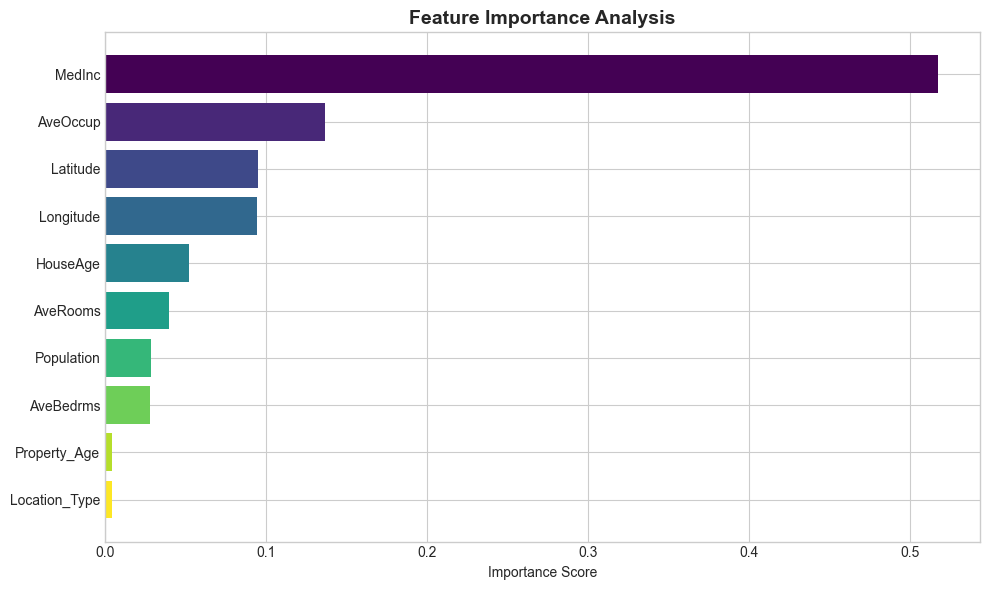

In [9]:
# Cell 9: Feature Importance Analysis
def analyze_feature_importance(dataframe, target_col='Target', method='sklearn'):
    """
    Calculate feature importance using Random Forest or SHAP.
    """
    print("\n" + "=" * 60)
    print("⭐ FEATURE IMPORTANCE ANALYSIS")
    print("=" * 60)
    
    # Prepare data
    df_clean = dataframe.copy()
    
    # Handle categorical variables
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    le = LabelEncoder()
    for col in cat_cols:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    
    # Handle missing values (simple imputation for this step)
    df_clean = df_clean.fillna(df_clean.median())
    
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]
    
    # Train model
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X, y)
    
    # Get importance
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n📊 Feature Importance (Random Forest):")
    print(importance.to_string(index=False))
    
    # Visualization
    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(importance)))
    plt.barh(importance['Feature'], importance['Importance'], color=colors)
    plt.xlabel('Importance Score')
    plt.title('Feature Importance Analysis', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # SHAP analysis if available
    if SHAP_AVAILABLE and method == 'shap':
        print("\n🔍 Generating SHAP values...")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X, show=False)
        plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return importance.to_dict('records')

importance_insights = analyze_feature_importance(df_missing, target_col='Target')


## 10. Step 8: Automated Insights Summary & Report Generation

The final step consolidates all findings into a structured report that can be exported.


In [11]:
# Cell 10: Automated Report Generation
def generate_insights_report(all_insights, output_format='dict'):
    """
    Generate a comprehensive insights report.
    """
    print("\n" + "=" * 60)
    print("📋 AUTOMATED INSIGHTS SUMMARY")
    print("=" * 60)
    
    report = {
        'generated_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'summary': {
            'total_insights_collected': len(all_insights),
            'pipeline_steps_completed': [
                'Initial Inspection',
                'Missing Value Analysis',
                'Outlier Detection',
                'Distribution Analysis',
                'Correlation Analysis',
                'Categorical Exploration',
                'Feature Importance'
            ]
        },
        'key_findings': {
            'dataset_shape': all_insights.get('initial', {}).get('shape'),
            'total_missing': all_insights.get('missing', {}),
            'highly_skewed_features': all_insights.get('distribution', []),
            'high_correlation_pairs': all_insights.get('correlation', {}).get('high_correlation_pairs', []),
            'top_features': all_insights.get('importance', [])[:3] if all_insights.get('importance') else []
        },
        'recommendations': [
            "Handle missing values in identified columns before modeling",
            "Consider log-transform for highly skewed features",
            "Investigate high correlation pairs for multicollinearity",
            "Focus on top 5 features for initial modeling efforts",
            "Validate categorical encoding strategy based on cardinality"
        ]
    }
    
    print(f"\n🎯 Report Generated: {report['generated_at']}")
    print(f"📊 Pipeline Steps: {len(report['summary']['pipeline_steps_completed'])}")
    print(f"\n💡 Key Recommendations:")
    for i, rec in enumerate(report['recommendations'], 1):
        print(f"   {i}. {rec}")
    
    if output_format == 'json':
        return json.dumps(report, indent=2, default=str)
    
    return report

# Compile all insights
all_insights = {
    'initial': initial_insights,
    'missing': missing_insights,
    'outliers': outlier_insights,
    'distribution': distribution_insights,
    'correlation': correlation_insights,
    'categorical': categorical_insights,
    'importance': importance_insights
}

final_report = generate_insights_report(all_insights)



📋 AUTOMATED INSIGHTS SUMMARY

🎯 Report Generated: 2026-04-14 20:32:47
📊 Pipeline Steps: 7

💡 Key Recommendations:
   1. Handle missing values in identified columns before modeling
   2. Consider log-transform for highly skewed features
   3. Investigate high correlation pairs for multicollinearity
   4. Focus on top 5 features for initial modeling efforts
   5. Validate categorical encoding strategy based on cardinality


## 11. Creating a Reusable EDA Pipeline Class

Now we combine all steps into a single, reusable class that can be imported and used on any dataset.


In [12]:
# Cell 11: The Complete EDAPipeline Class
class EDAPipeline:
    """
    A comprehensive, reusable EDA pipeline for data analysis.
    
    Usage:
        pipeline = EDAPipeline()
        pipeline.run_full_pipeline(dataframe, target_col='Target')
    """
    
    def __init__(self, output_dir='./eda_outputs'):
        self.output_dir = output_dir
        self.insights = {}
        self.report = {}
        self.figures = []
        
        # Create output directory
        os.makedirs(output_dir, exist_ok=True)
        
        print("✅ EDAPipeline initialized successfully!")
    
    def run_full_pipeline(self, dataframe, target_col=None, categorical_cols=None):
        """
        Execute the complete EDA pipeline.
        """
        print("\n" + "=" * 70)
        print("🚀 RUNNING FULL EDA PIPELINE")
        print("=" * 70)
        
        start_time = datetime.now()
        
        # Step 1: Initial Inspection
        self.insights['initial'] = self._initial_inspection(dataframe)
        
        # Step 2: Missing Values
        self.insights['missing'] = self._analyze_missing_values(dataframe)
        
        # Step 3: Outliers
        numerical_cols = dataframe.select_dtypes(include=[np.number]).columns.tolist()
        self.insights['outliers'] = self._detect_outliers(dataframe, numerical_cols)
        
        # Step 4: Distributions
        self.insights['distribution'] = self._analyze_distributions(dataframe, numerical_cols)
        
        # Step 5: Correlations
        self.insights['correlation'] = self._analyze_correlations(dataframe, target_col)
        
        # Step 6: Categorical
        if categorical_cols is None:
            categorical_cols = dataframe.select_dtypes(include=['object']).columns.tolist()
        self.insights['categorical'] = self._explore_categorical(dataframe, categorical_cols)
        
        # Step 7: Feature Importance
        if target_col and target_col in dataframe.columns:
            self.insights['importance'] = self._analyze_feature_importance(dataframe, target_col)
        
        # Step 8: Generate Report
        self.report = self._generate_report()
        
        end_time = datetime.now()
        duration = (end_time - start_time).total_seconds()
        
        print(f"\n✅ Pipeline completed in {duration:.2f} seconds!")
        print(f"📊 Insights collected: {len(self.insights)} categories")
        
        return self.report
    
    def _initial_inspection(self, dataframe):
        """Step 1: Data Loading & Initial Inspection"""
        return {
            'shape': dataframe.shape,
            'columns': list(dataframe.columns),
            'dtypes': dict(dataframe.dtypes.value_counts()),
            'memory_mb': round(dataframe.memory_usage(deep=True).sum() / 1024**2, 2),
            'null_total': int(dataframe.isnull().sum().sum()),
            'duplicates': int(dataframe.duplicated().sum())
        }
    
    def _analyze_missing_values(self, dataframe):
        """Step 2: Missing Value Analysis"""
        missing = dataframe.isnull().sum()
        missing_pct = (missing / len(dataframe) * 100).round(2)
        
        missing_dict = {}
        for col in dataframe.columns:
            if missing[col] > 0:
                missing_dict[col] = {
                    'count': int(missing[col]),
                    'percentage': float(missing_pct[col])
                }
        return missing_dict
    
    def _detect_outliers(self, dataframe, numerical_cols, method='iqr'):
        """Step 3: Outlier Detection"""
        outlier_dict = {}
        for col in numerical_cols:
            data = dataframe[col].dropna()
            Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
            IQR = Q3 - Q1
            outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
            outlier_dict[col] = {
                'count': len(outliers),
                'percentage': round(len(outliers)/len(data)*100, 2)
            }
        return outlier_dict
    
    def _analyze_distributions(self, dataframe, numerical_cols):
        """Step 4: Distribution Analysis"""
        dist_list = []
        for col in numerical_cols:
            data = dataframe[col].dropna()
            dist_list.append({
                'feature': col,
                'skewness': round(stats.skew(data), 3),
                'kurtosis': round(stats.kurtosis(data), 3),
                'mean': round(data.mean(), 3),
                'median': round(data.median(), 3)
            })
        return dist_list
    
    def _analyze_correlations(self, dataframe, target_col):
        """Step 5: Correlation Analysis"""
        numerical_df = dataframe.select_dtypes(include=[np.number])
        corr_matrix = numerical_df.corr()
        
        result = {'matrix': corr_matrix.to_dict()}
        
        if target_col and target_col in corr_matrix.columns:
            result['target_corr'] = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False).to_dict()
        
        # High correlation pairs
        high_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.7:
                    high_pairs.append({
                        'f1': corr_matrix.columns[i],
                        'f2': corr_matrix.columns[j],
                        'corr': round(corr_matrix.iloc[i, j], 3)
                    })
        result['high_pairs'] = high_pairs
        
        return result
    
    def _explore_categorical(self, dataframe, categorical_cols):
        """Step 6: Categorical Exploration"""
        cat_dict = {}
        for col in categorical_cols:
            cat_dict[col] = {
                'unique': int(dataframe[col].nunique()),
                'top': str(dataframe[col].mode()[0]) if not dataframe[col].mode().empty else None,
                'nulls': int(dataframe[col].isnull().sum())
            }
        return cat_dict
    
    def _analyze_feature_importance(self, dataframe, target_col):
        """Step 7: Feature Importance"""
        df_clean = dataframe.copy()
        
        # Encode categoricals
        for col in df_clean.select_dtypes(include=['object']):
            df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))
        
        df_clean = df_clean.fillna(df_clean.median())
        
        X = df_clean.drop(columns=[target_col])
        y = df_clean[target_col]
        
        model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        model.fit(X, y)
        
        importance = []
        for feat, imp in zip(X.columns, model.feature_importances_):
            importance.append({'feature': feat, 'importance': round(imp, 4)})
        
        return sorted(importance, key=lambda x: x['importance'], reverse=True)
    
    def _generate_report(self):
        """Step 8: Generate Final Report"""
        return {
            'timestamp': datetime.now().isoformat(),
            'summary': {
                'rows': self.insights['initial']['shape'][0],
                'columns': self.insights['initial']['shape'][1],
                'missing_columns': len(self.insights['missing']),
                'high_correlations': len(self.insights['correlation'].get('high_pairs', [])),
                'top_feature': self.insights.get('importance', [{}])[0].get('feature') if self.insights.get('importance') else None
            },
            'insights': self.insights
        }
    
    def save_report(self, filename='eda_report.json'):
        """Save report to JSON file"""
        filepath = os.path.join(self.output_dir, filename)
        with open(filepath, 'w') as f:
            json.dump(self.report, f, indent=2, default=str)
        print(f"💾 Report saved to: {filepath}")
        return filepath

print("✅ EDAPipeline class defined successfully!")


✅ EDAPipeline class defined successfully!


## 12. Running the Pipeline on a New Dataset

Let's demonstrate the full pipeline on our dataset to prove it works end-to-end.


In [13]:
# Cell 12: Execute Full Pipeline
# Initialize pipeline
pipeline = EDAPipeline(output_dir='./eda_day50_outputs')

# Run on our dataset
report = pipeline.run_full_pipeline(
    dataframe=df_missing,
    target_col='Target',
    categorical_cols=['Location_Type', 'Property_Age']
)

print("\n" + "=" * 70)
print("📊 PIPELINE EXECUTION SUMMARY")
print("=" * 70)
print(f"Dataset: {report['summary']['rows']:,} rows × {report['summary']['columns']} columns")
print(f"Columns with missing data: {report['summary']['missing_columns']}")
print(f"High correlation pairs detected: {report['summary']['high_correlations']}")
print(f"Most important feature: {report['summary']['top_feature']}")


✅ EDAPipeline initialized successfully!

🚀 RUNNING FULL EDA PIPELINE

✅ Pipeline completed in 8.57 seconds!
📊 Insights collected: 7 categories

📊 PIPELINE EXECUTION SUMMARY
Dataset: 20,640 rows × 11 columns
Columns with missing data: 3
High correlation pairs detected: 2
Most important feature: MedInc


In [ ]:
# Cell 13: Save and Display Report

# Display key insights
print("\n🔍 DETAILED INSIGHTS:")
print("-" * 50)
print("\n1️⃣ Initial Inspection:")
print(f"   • Memory usage: {pipeline.insights['initial']['memory_mb']} MB")
print(f"   • Duplicate rows: {pipeline.insights['initial']['duplicates']}")

print("\n2️⃣ Missing Values:")
for col, info in list(pipeline.insights['missing'].items())[:3]:
    print(f"   • {col}: {info['count']} ({info['percentage']}%)")

print("\n3️⃣ Top 3 Most Important Features:")
for feat in pipeline.insights.get('importance', [])[:3]:
    print(f"   • {feat['feature']}: {feat['importance']:.4f}")



🔍 DETAILED INSIGHTS:
--------------------------------------------------

1️⃣ Initial Inspection:
   • Memory usage: 1.94 MB
   • Duplicate rows: 0

2️⃣ Missing Values:
   • AveRooms: 1014 (4.91%)
   • AveBedrms: 1051 (5.09%)
   • Population: 1028 (4.98%)

3️⃣ Top 3 Most Important Features:
   • MedInc: 0.5178
   • AveOccup: 0.1370
   • Latitude: 0.0940


In [16]:
# Cell 14: Demonstration on Different Dataset (Iris for Classification)
from sklearn.datasets import load_iris

print("\n" + "=" * 70)
print("🌸 BONUS: Testing Pipeline on Iris Dataset")
print("=" * 70)

# Load Iris
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = [iris.target_names[i] for i in iris.target]
df_iris['Target'] = iris.target

# Run pipeline
pipeline_iris = EDAPipeline(output_dir='./eda_day50_outputs')
iris_report = pipeline_iris.run_full_pipeline(
    dataframe=df_iris,
    target_col='Target',
    categorical_cols=['species']
)

print(f"\n✅ Iris pipeline completed!")
print(f"📊 Shape: {iris_report['summary']['rows']} × {iris_report['summary']['columns']}")
print(f"🎯 Top feature: {iris_report['summary']['top_feature']}")



🌸 BONUS: Testing Pipeline on Iris Dataset
✅ EDAPipeline initialized successfully!

🚀 RUNNING FULL EDA PIPELINE

✅ Pipeline completed in 0.30 seconds!
📊 Insights collected: 7 categories

✅ Iris pipeline completed!
📊 Shape: 150 × 6
🎯 Top feature: species


## 🛠️ Hands-On Exercises & Challenges

Now it's your turn to extend and master this pipeline!


### Exercise 1: Extend with Statistical Tests
Add a method to perform statistical tests (t-test, chi-square, ANOVA) to validate feature significance. Integrate it into the pipeline.


In [17]:
# Exercise 1: Your code here



### Exercise 2: Apply to Real-World Dataset
Download a dataset from Kaggle (e.g., Titanic, House Prices, or Customer Churn) and run the full pipeline. Document 3 key insights you discovered.


In [18]:
# Exercise 2: Your code here



### Exercise 3: Custom Visualization Functions
Create custom plotting functions for:
- Pair plots for top correlated features
- Time series decomposition (if temporal data exists)
- Geographic visualizations (if location data exists)


In [19]:
# Exercise 3: Your code here



### Exercise 4: Interactive HTML Report
Modify the `save_report` method to generate an interactive HTML report using templates or libraries like `ydata-profiling` integration.


In [20]:
# Exercise 4: Your code here



### Exercise 5: Version Control Friendly Outputs
Create a method that exports EDA results in a format friendly for Git (markdown tables, small PNGs, text summaries) to track changes in data over time.


In [21]:
# Exercise 5: Your code here



### Exercise 6: Large Dataset Optimization
Optimize the pipeline for datasets > 1GB by:
- Adding sampling options
- Using Dask for parallel processing
- Implementing chunked processing for visualizations


In [22]:
# Exercise 6: Your code here



### Exercise 7: Automated Data Quality Scoring
Implement a scoring system (0-100) that rates dataset quality based on:
- Missing value percentage
- Outlier severity
- Class balance (for classification)
- Duplicate ratio


In [23]:
# Exercise 7: Your code here



### Exercise 8: Pipeline Comparison Mode
Add functionality to compare two datasets (e.g., train vs test) and highlight distribution shifts, missing value pattern differences, etc.


In [24]:
# Exercise 8: Your code here



### Exercise 9: Integration with MLflow/Experiment Tracking
Extend the pipeline to log EDA artifacts (plots, reports) to MLflow or Weights & Biases for experiment tracking.


In [25]:
# Exercise 9: Your code here



### Exercise 10: CLI Interface
Create a command-line interface (using `argparse` or `click`) so the pipeline can be run as: `python eda_pipeline.py --input data.csv --target price --output report.html`


In [26]:
# Exercise 10: Your code here



## Solutions & Advanced Extensions

### Solution 1: Statistical Tests Integration

```python
def add_statistical_tests(self, dataframe, target_col):
    from scipy.stats import f_oneway, chi2_contingency, ttest_ind
    
    results = {}
    numerical = dataframe.select_dtypes(include=[np.number]).columns
    categorical = dataframe.select_dtypes(include=['object']).columns
    
    # ANOVA for numerical vs target
    if target_col in categorical:
        for num_col in numerical:
            groups = [group[num_col].values for name, group in dataframe.groupby(target_col)]
            f_stat, p_value = f_oneway(*groups)
            results[f'{num_col}_vs_{target_col}'] = {'f_stat': f_stat, 'p_value': p_value}
    
    return results
```

### Solution 2: HTML Report Generation

Use Jinja2 templates to create beautiful HTML reports:
```python
from jinja2 import Template

html_template = """
<html>
<head><title>EDA Report</title></head>
<body>
<h1>EDA Report for {{ dataset_name }}</h1>
<p>Generated: {{ timestamp }}</p>
<h2>Summary</h2>
<ul>
<li>Rows: {{ summary.rows }}</li>
<li>Columns: {{ summary.columns }}</li>
</ul>
</body>
</html>
"""
```

### Solution 3: Large Dataset Handling

```python
import dask.dataframe as dd

def load_large_dataset(self, filepath):
    # Use Dask for out-of-core processing
    ddf = dd.read_csv(filepath)
    # Sample for EDA while keeping full data for final processing
    sample = ddf.sample(frac=0.1).compute()
    return sample
```

### Advanced Extensions:

1. **Automated Feature Engineering Suggestions**: Use libraries like `featuretools` to suggest new features based on existing ones
2. **Data Drift Detection**: Compare training vs. production data distributions
3. **Privacy Check**: Automatically detect potential PII (Personally Identifiable Information)
4. **Time-Aware EDA**: Special handling for temporal features (seasonality, trends)
5. **Multi-Table EDA**: Support for relational databases with automatic relationship detection


## 🎉 Congratulations!

**You have completed the full Exploratory Data Analysis Mastery phase!**

Over the past 20 days (Days 31–50), you've transformed from someone who simply "looks at data" into a professional data explorer who:

✅ Understands data quality issues and how to fix them  
✅ Detects patterns, outliers, and anomalies with statistical rigor  
✅ Creates publication-quality visualizations  
✅ Identifies relationships and feature importance  
✅ Builds reusable, production-ready tools  

This EDA pipeline is now yours — customize it, extend it, and use it on every project. It's your competitive advantage.

---

## 🚀 Tomorrow: Day 51 - Classical Machine Learning Begins!

Get ready for the next major phase of your journey. **Tomorrow we begin Classical Machine Learning with Linear Regression from Scratch + Scikit-Learn.**

You'll learn:
- The mathematics behind linear regression (gradient descent, cost functions)
- Building models from scratch using only NumPy
- Production-ready implementations with scikit-learn
- Model evaluation metrics and interpretation

The foundation you've built in EDA will now power your machine learning models. Clean data + solid EDA = superior model performance.

---

**You now possess a professional-grade EDA skillset ready for real-world AI projects.**

Keep building. Keep exploring. The best is yet to come.

---

*Python & AI Learning Path | Day 50 / 369* ⭐
